In [2]:
from hybrid_surr import plot_hyb
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import numpy as np
import arviz as az
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, top_k_accuracy_score
#from io import BytesIO
from hybrid_surr import plot_funcs, aux_f,surr_funcs
warnings.filterwarnings(action='ignore')

# to account for updates when files change
%load_ext autoreload
%autoreload 2

In [8]:
for k in ['sw_incidence_100k','sw_beta_100k',
             'ba_incidence_100k','ba_beta_100k']:
    df = pd.read_csv(f'hybrid_surr/aux_hyb/{k}.csv',
                        skiprows=lambda x: x > 0 and (x - 1) % 10 != 0)
    #df.to_csv(f'hybrid_surr/aux_hyb/{k}_10p.csv', index=False)

In [11]:
df = pd.read_csv('hybrid_surr/aux_hyb/sw_incidence_100k_10p.csv',
                    #skiprows=lambda x: x > 0 and (x - 1) % 10 != 0
                )
_, df = train_test_split(df, test_size=2400, 
                         random_state=42, stratify=None)

pt = df.iloc[:,5:].values.argmax(axis=1)+1
ph = df.iloc[:,5:].values.max(axis=1)

new_df = df.iloc[:,[0,4]]
new_df = new_df.round(2)
new_df['actual_peak_Inc'] = ph
new_df['actual_peak_day_Inc'] = pt
new_df

,beta,alpha,actual_peak_Inc,actual_peak_day_Inc
3098,0.49,0.79,1402.0,109
2531,0.42,0.72,936.0,164
4071,0.61,0.92,2430.0,100
1287,0.27,0.28,1.0,8
2540,0.42,0.81,1257.0,138
...,...,...,...,...
6865,0.96,0.86,2920.0,77
6356,0.80,0.57,1288.0,105
3378,0.53,0.39,303.0,220
4032,0.61,0.53,813.0,140


## plots

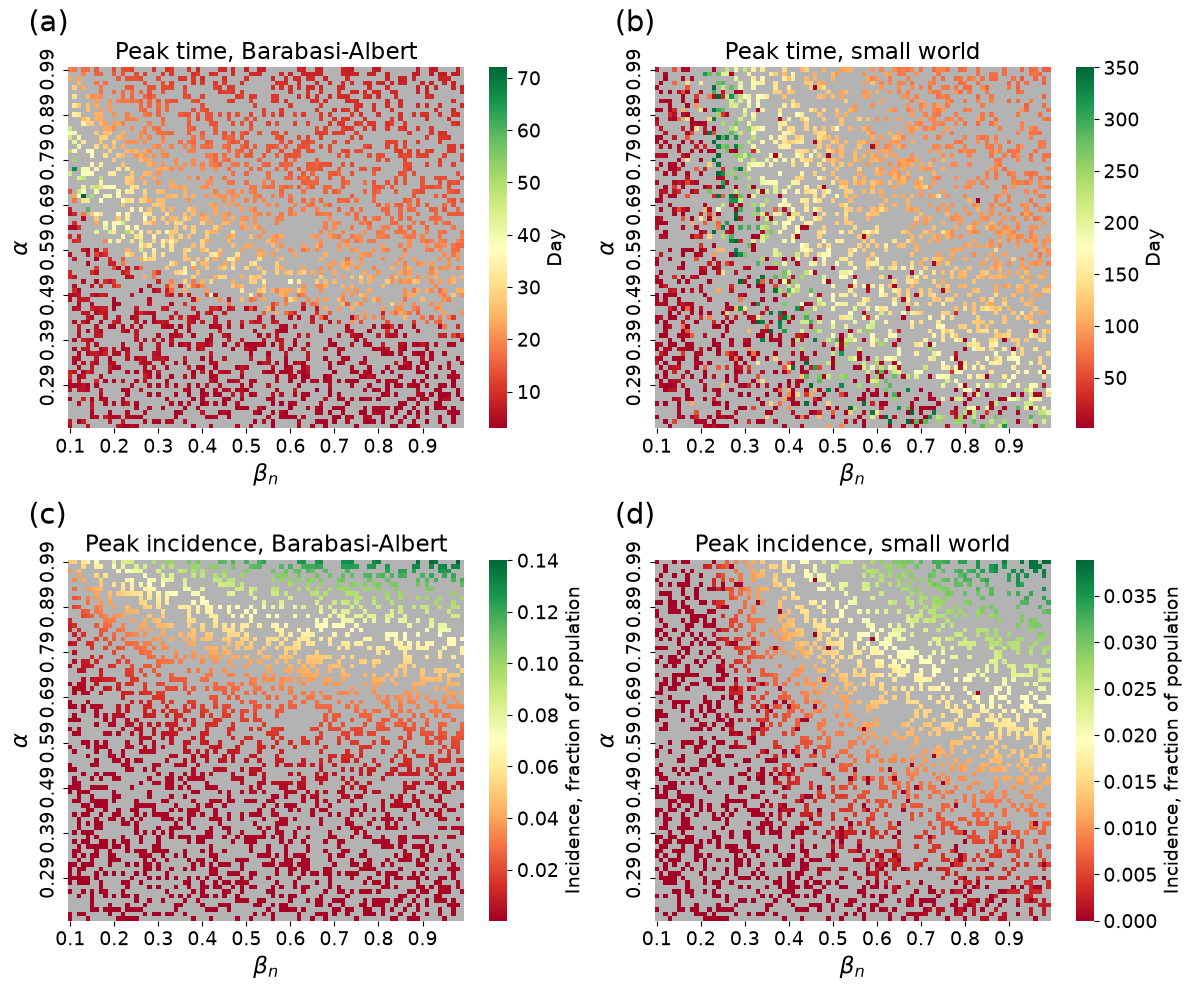

In [10]:
# PEAK INFECTED
fig, axes = plt.subplots(2,2, figsize=(12,10))
ax = axes.flatten()

heat_orig = aux_f.heatmap_orig_peaks(topology='ba',folder='hybrid_surr/aux_hyb/')
aux_f.peaks_hmaps(heat_orig, with_inc=True, title=', Barabasi-Albert', 
                  ax=[ax[0],ax[2]], n=['(a)','(c)'])
heat_orig = aux_f.heatmap_orig_peaks(topology='sw',folder='hybrid_surr/aux_hyb/')
aux_f.peaks_hmaps(heat_orig, with_inc=True, title=', small world', 
                  ax=[ax[1],ax[3]], n=['(b)','(d)'])

#plt.savefig(f'results/ba100_actual.pdf', format='pdf', bbox_inches='tight')

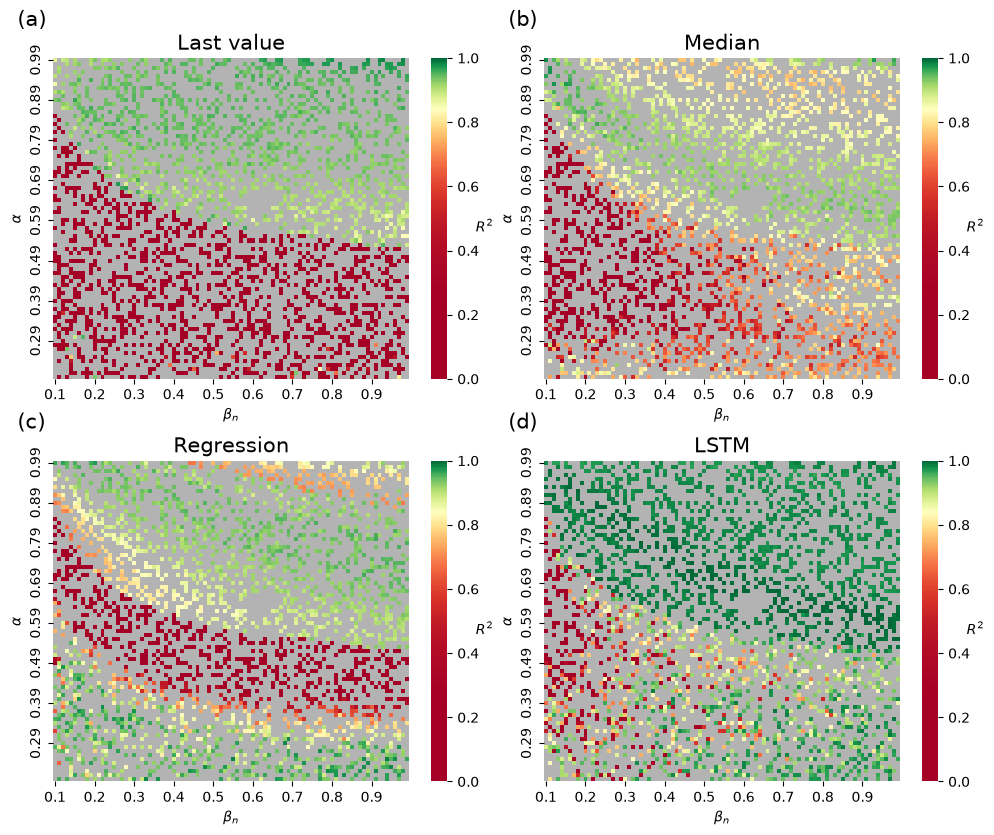

In [134]:
l=5
fin_inc = aux_f.df_metrics(folder_name='hybrid_surr/aux_hyb/',
                        top_name='new_ba_100000', 
                       test_suff='ba_', 
                       switch='fraq_people',
                       with_inc=True, 
                       trim=False, suff=f'_ba100k_sI_fullR_{l}')

aux_f.metric_hmaps(folder_name='hybrid_surr/aux_hyb/',
                   fin=fin_inc, met='r2_Inc', suff=f'_ba_sI_{l}', 
                   exclude=['Cumulative Average',
                            'Exponential Decay'],
                    save=False)


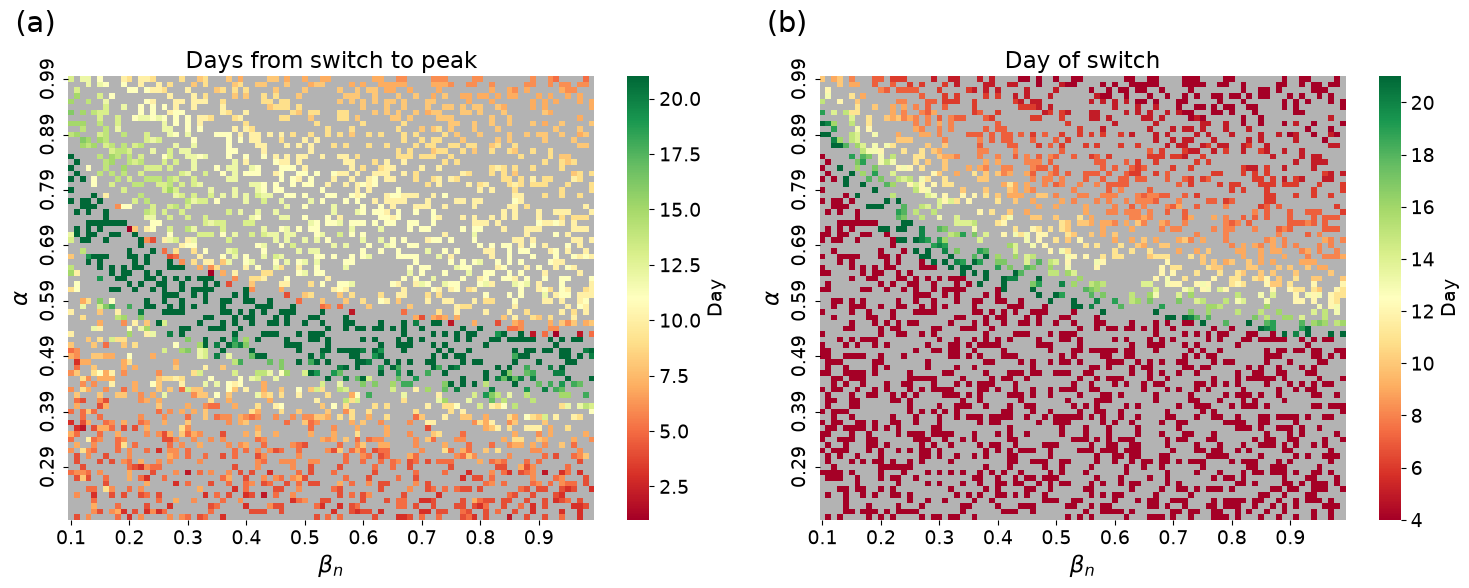

In [13]:
aux_f.smth_hmaps(fin_inc, 21)

## hybrid

In [130]:
types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']
methods = ['last value','expanding mean last value',
            'median beta', 'regression beta', 'lstm' ]
new_labels = ['last_value', 'expanding_mean_last_value', 
            'median_beta',  'regression_beta', 'lstm_day_E_previous_I'
             ]

sigma=0.3
gamma=0.2
perc_switch=0.01
stoch=10

seed_dirs="../long_sw_100000_fin/"
#seed_dirs="../new_ba_100000/"
sw = pd.read_csv('hybrid_surr/aux_hyb/test_files.csv').values

In [318]:
%%time
df = pd.read_csv('hybrid_surr/aux_hyb/ba_incidence_100k.csv',
                skiprows=lambda x: x > 0 and (x - 1) % 10 != 0)
_,test_df = train_test_split(df, test_size=2400, 
                             random_state=42, stratify=None)
dfb = pd.read_csv('hybrid_surr/aux_hyb/ba_beta_100k.csv',
                 skiprows=lambda x: x > 0 and (x - 1) % 10 != 0)
_,test_dfb  = train_test_split(dfb, test_size=2400, 
                             random_state=42, stratify=None)
test_dfb

CPU times: total: 1.03 s
Wall time: 1.05 s


,beta,gamma,delta,init_inf_frac,alpha,0,1,2,3,4,...,140,141,142,143,144,145,146,147,148,149
3098,0.48,0.3,0.2,0.0001,0.78,0.001653,0.000063,0.000022,0.000015,0.000014,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2531,0.41,0.3,0.2,0.0001,0.71,0.001482,0.000081,0.000025,0.000016,0.000013,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4071,0.60,0.3,0.2,0.0001,0.91,0.002335,0.000073,0.000039,0.000031,0.000025,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1287,0.26,0.3,0.2,0.0001,0.28,0.000779,0.000125,0.000036,0.000019,0.000009,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2540,0.41,0.3,0.2,0.0001,0.80,0.001635,0.000073,0.000026,0.000018,0.000015,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6865,0.95,0.3,0.2,0.0001,0.85,0.003210,0.000086,0.000041,0.000031,0.000027,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
6356,0.89,0.3,0.2,0.0001,0.56,0.002488,0.000071,0.000023,0.000016,0.000012,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
3378,0.52,0.3,0.2,0.0001,0.38,0.001453,0.000098,0.000026,0.000013,0.000009,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4032,0.60,0.3,0.2,0.0001,0.52,0.001404,0.000066,0.000020,0.000014,0.000010,...,0.000004,0.000004,-0.0,0.000011,0.000004,0.000004,0.000007,-0.0,-0.0,0.0


path:  hybrid_surr/aux_hyb/ba100k_regression_bt.joblib
was there? 51
5 1000.0 fraq_people 0.01
was there? 46
5 1000.0 fraq_people 0.01
CPU times: total: 719 ms
Wall time: 791 ms


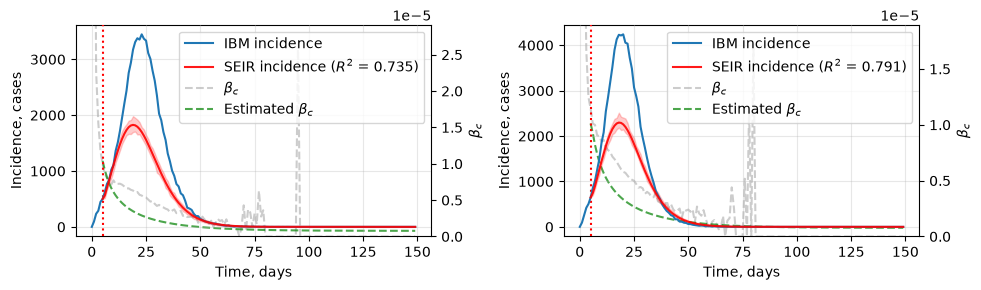

In [38]:
%%time
k = 200
sw = pd.read_csv('hybrid_surr/aux_hyb/ba_test_files.csv').values
plot_hyb.apply_methods(seed_dirs="../new_ba_100k/new_ba_100k/",
              seed_numbers=sw[::10][k:k+2], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=4, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01, stoch=100, 
                m_folder='hybrid_surr/aux_hyb/',
             suff_m='ba100k', suff='ba100k_10')

In [86]:
for k in [93,2390]:
    print(sw[::10][k:k+1])

[['p_0.13_0.3_0.2_0.0001_0.3900000000000002_seed_0.csv']]
[['p_0.9899999999999995_0.3_0.2_0.0001_0.6300000000000003_seed_0.csv']]


was there? 0
4 5000.0 fraq_people 0.05
was there? 0
4 5000.0 fraq_people 0.05
was there? 23
10 5000.0 fraq_people 0.05
was there? 23
10 5000.0 fraq_people 0.05


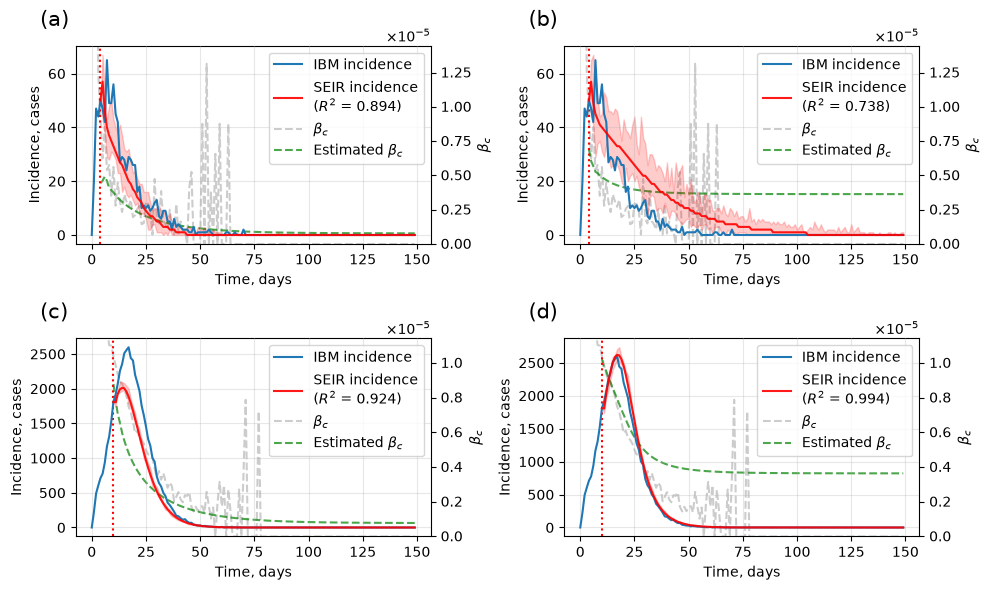

In [230]:

fig, ax = plt.subplots(2,2, figsize=(10, 6))
ax = ax.flatten()
f = 'hybrid_surr/aux_hyb/'
types_start_day = ['fraq_people']
methods = ['last value','expanding mean last value',
               'median beta','regression beta', 'lstm']
#seed_dirs = '../new_ba_100k/new_ba_100k/'
seed_dirs = f'{folder_main}/aux_hyb/'
model_pathr = f+f'ba100k_regression_bt.joblib'
model_pathl = f+f'ba100k_lstm_4_001_s10'   

sigma=0.3
gamma=0.2
perc_switch=0.05
stoch=10
j=0
labs = ['(a)','(b)','(c)','(d)'][::-1]
#[93,2390] sw[::10][k:k+1]
files_h = ['p_0.13_0.3_0.2_0.0001_0.3900000000000002_seed_0.csv',
           'p_0.9899999999999995_0.3_0.2_0.0001_0.6300000000000003_seed_0.csv']
methods=['regression beta', 'lstm']
for k in files_h:
    for method,model_path in zip(methods,
                                [model_pathr,model_pathl]):
        _=plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=stoch, 
                        beta_prediction_method=method, 
                        type_start_day=types_start_day[0], 
                        seed_numbers=[[k]], show_fig_flag=True,
                        seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                        ax=[ax[j]], model_path=model_path,perc_switch=perc_switch,
                        is_filename=True,on_incidence=True,
                        switch_on_incidence=False)
        ax[j].text(-0.1, 1.1, labs.pop(),
                   transform=ax[j].transAxes, size=15)
        j+=1
        

plt.tight_layout()

### synthetic incidence and betas

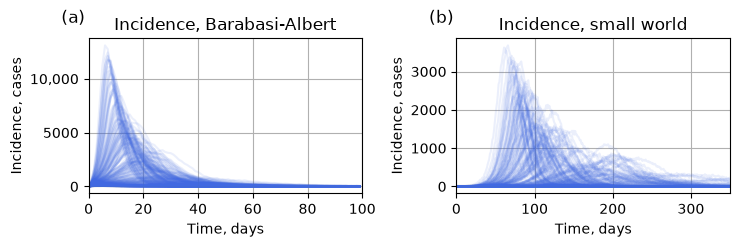

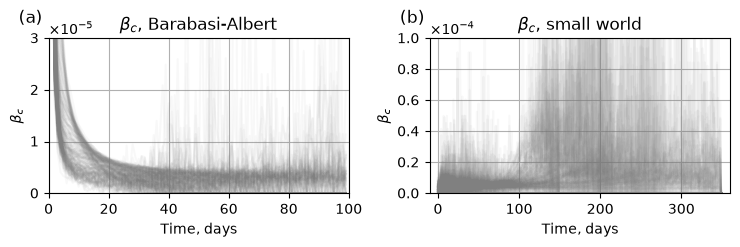

In [125]:
aux_f.plot_synth_inc_beta(folder='hybrid_surr/aux_hyb/',save_folder='.')

## surrogate

In [15]:
folder = 'hybrid_surr/calibr/'
folder

'hybrid_surr/calibr/'

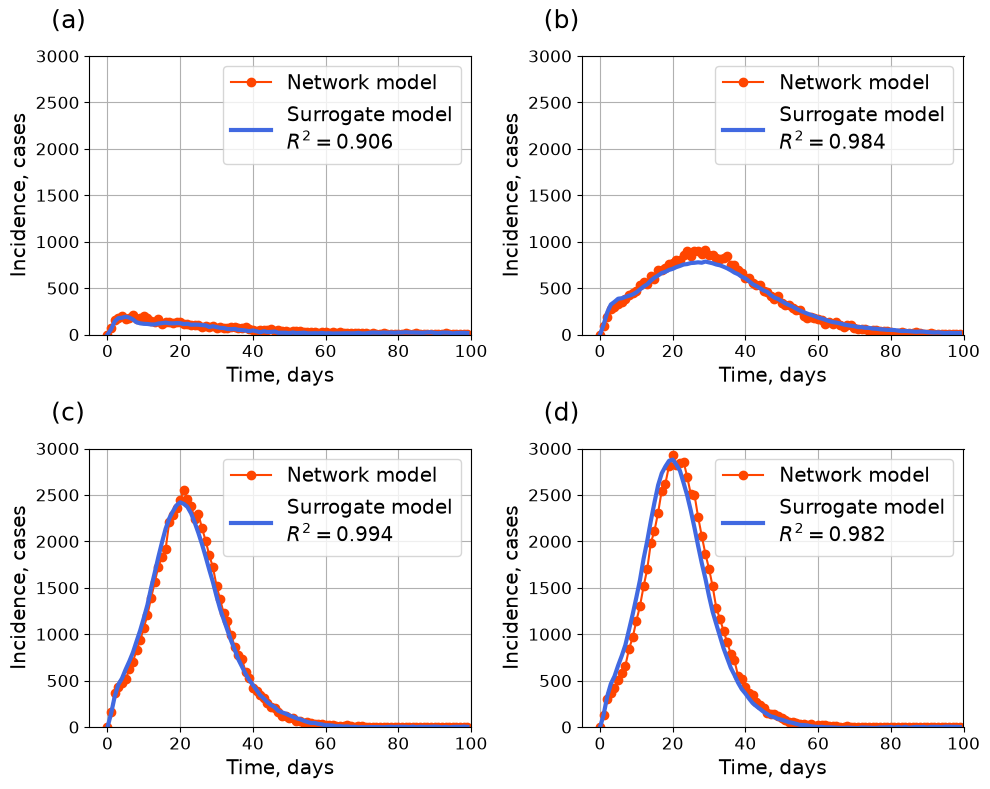

In [150]:
type_df = 'point'
folder_main = 'hybrid_surr/'
topology='ba'
test_indices = [11,7,1,15]
ae = torch.load(f'{folder_main}/calibr//models/autoencoder_{topology}_100k_n.pt', 
                    weights_only=False)
X_train, y_train, X_test, y_test,tmax = \
    surr_funcs.get_splits_df(folder=folder_main+'calibr/', 
                             type_df=type_df, network_type = topology)
fontsize = 12
rows, cols = 2, 2
fig, ax = plt.subplots(rows, cols, figsize=(10, 8))
labels = ['(a)', '(b)', '(c)', '(d)']
counter = 0
cut = 100
alpha_beta, r2s = [], []
for row in range(rows):
    for col in range(cols):
        surrogate_sim = surr_funcs.predict(ae, 
                                           X_test[test_indices[counter]]
                                          ).numpy()
        r2 = r2_score(y_test[test_indices[counter]], surrogate_sim)
        #print(labels[counter], test_indices[counter], X_test[test_indices[counter]])
        r2s.append(r2)
        alpha_beta.append(X_test[test_indices[counter]])
        
        ax[row][col].plot(y_test[test_indices[counter]][:cut], 
                          label='Network model', marker='o', 
                          color='OrangeRed')
        ax[row][col].plot(surrogate_sim[:cut], lw=3, color='RoyalBlue', 
                          label=f'Surrogate model\n$R^2=${r2:.3f}')

        ax[row][col].set_xlabel('Time, days', fontsize=1.2*fontsize)
        ax[row][col].set_ylabel('Incidence, cases', fontsize=1.2*fontsize)
        ax[row][col].set_ylim(0, 3000)
        ax[row][col].set_xlim(-5, 100)
        ax[row][col].tick_params(axis='both', which='major', 
                                 labelsize=fontsize)
        ax[row][col].legend(fontsize=1.2*fontsize)
        ax[row][col].grid()
        
        # Add subplot label outside the top-left corner
        ax[row][col].text(-0.1, 1.1, labels[counter],
                    transform=ax[row][col].transAxes, size=fontsize*1.5)
        counter += 1

plt.tight_layout() 
metadata = {
        'R2 for test samples': r2s,
        'Alpha of test samples': np.array(alpha_beta)[:,0],
        'Beta of test samples': np.array(alpha_beta)[:,1],
        #**artifact_metadata,
    }

In [177]:
type_df ='interval'
network_type='ba'
df = pd.read_csv(folder+f'/{network_type}_{type_df}_dataset.csv', 
                     index_col=0)
tmax = int((df.values.shape[1] - 5)/3)
df['ts'] = df[['incidence_' + str(day_index) \
               for day_index in range(tmax)] + \
              ['low_incidence_' + str(day_index) \
               for day_index in range(tmax)] + \
              ['high_incidence_' + str(day_index) \
               for day_index in range(tmax)
              ]].values.tolist()
data = df[['beta', 'alpha', 'ts']]
X = data.drop(columns=['ts'])#[['file']]
y = data['ts']
    
X_train, X_test = train_test_split(X, test_size=2400, 
                                   random_state=42, stratify=None)
X_train, X_test = X_train.values, X_test.values
folder_all=folder_main+'aux_hyb/'
qw = pd.read_csv(folder_all+f'{network_type}_incidence_100k.csv').reset_index(drop=True)
qw['group'] = qw.index//10
mtr, mtest = train_test_split(X, test_size=2400, 
                              random_state=42, stratify=None)

In [179]:
qw

,beta,gamma,delta,init_inf_frac,alpha,0,1,2,3,4,...,141,142,143,144,145,146,147,148,149,group
0,0.11,0.3,0.2,0.0001,0.21,0.0,14.0,23.0,32.0,48.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.11,0.3,0.2,0.0001,0.21,0.0,7.0,23.0,33.0,37.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.11,0.3,0.2,0.0001,0.21,0.0,4.0,21.0,19.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.11,0.3,0.2,0.0001,0.21,0.0,10.0,20.0,34.0,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.11,0.3,0.2,0.0001,0.21,0.0,11.0,20.0,36.0,34.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71995,0.99,0.3,0.2,0.0001,0.99,0.0,732.0,2626.0,6148.0,10861.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7199
71996,0.99,0.3,0.2,0.0001,0.99,0.0,624.0,2312.0,5437.0,10000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7199
71997,0.99,0.3,0.2,0.0001,0.99,0.0,765.0,2617.0,6139.0,10572.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7199
71998,0.99,0.3,0.2,0.0001,0.99,0.0,582.0,1954.0,4812.0,9340.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7199


### saving 4 test index 10 seeds for Surrogate Interval

In [189]:
h = pd.DataFrame([])
counter=0
test_indices = [1101,7,1,150]
for ti in test_indices:
    print(X_test[ti])
    real_idx = mtest.iloc[ti].name
    part = qw[qw.group==real_idx]#.iloc[:,5:-1]
    h = pd.concat([h,part])
#h.to_csv('hybrid_surr/aux_hyb/ba_4id_10samples.csv',index=False)
h

[0.83 0.32]
[0.4  0.59]
[0.41 0.71]
[0.66 0.6 ]


,beta,gamma,delta,init_inf_frac,alpha,0,1,2,3,4,...,141,142,143,144,145,146,147,148,149,group
58520,0.83,0.3,0.2,0.0001,0.32,0.0,108.0,179.0,185.0,186.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58521,0.83,0.3,0.2,0.0001,0.32,0.0,98.0,188.0,214.0,210.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58522,0.83,0.3,0.2,0.0001,0.32,0.0,92.0,165.0,195.0,168.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58523,0.83,0.3,0.2,0.0001,0.32,0.0,106.0,183.0,208.0,192.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58524,0.83,0.3,0.2,0.0001,0.32,0.0,110.0,188.0,209.0,212.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58525,0.83,0.3,0.2,0.0001,0.32,0.0,97.0,156.0,182.0,180.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58526,0.83,0.3,0.2,0.0001,0.32,0.0,99.0,172.0,191.0,163.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58527,0.83,0.3,0.2,0.0001,0.32,0.0,100.0,181.0,196.0,159.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58528,0.83,0.3,0.2,0.0001,0.32,0.0,105.0,184.0,184.0,178.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852
58529,0.83,0.3,0.2,0.0001,0.32,0.0,120.0,200.0,156.0,158.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5852


In [208]:
test_indices = [1101,7,1,150]
for ti in test_indices:
    
    b,a = X_test[test_indices[counter]]
    print(round(a,2),round(b,2))
    #real_idx = mtest.iloc[ti].name
    part = h[(h.beta.round(2)==round(b,2))&(h.alpha.round(2)==round(a,2))].iloc[:,5:-1]
    print(part.shape)
part

0.32 0.83
(10, 150)
0.32 0.83
(10, 150)
0.32 0.83
(10, 150)
0.32 0.83
(10, 150)


,0,1,2,3,4,5,6,7,8,9,...,140,141,142,143,144,145,146,147,148,149
58520,0.0,108.0,179.0,185.0,186.0,164.0,162.0,151.0,122.0,139.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58521,0.0,98.0,188.0,214.0,210.0,198.0,176.0,169.0,142.0,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58522,0.0,92.0,165.0,195.0,168.0,173.0,155.0,129.0,161.0,111.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58523,0.0,106.0,183.0,208.0,192.0,180.0,164.0,145.0,144.0,140.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58524,0.0,110.0,188.0,209.0,212.0,197.0,175.0,169.0,144.0,134.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58525,0.0,97.0,156.0,182.0,180.0,160.0,143.0,148.0,132.0,125.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58526,0.0,99.0,172.0,191.0,163.0,141.0,135.0,108.0,133.0,148.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58527,0.0,100.0,181.0,196.0,159.0,132.0,159.0,128.0,153.0,114.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58528,0.0,105.0,184.0,184.0,178.0,158.0,168.0,163.0,128.0,126.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58529,0.0,120.0,200.0,156.0,158.0,130.0,139.0,127.0,98.0,93.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


CPU times: total: 406 ms
Wall time: 400 ms


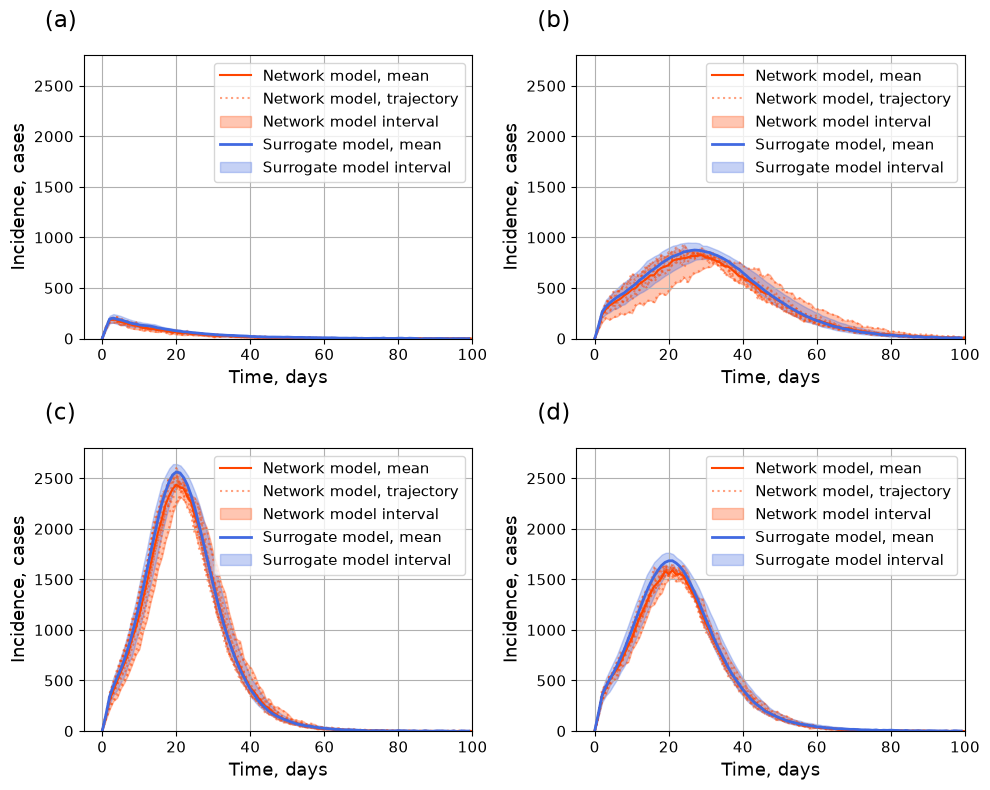

In [213]:
%%time
topology='ba'
test_indices = [1101,7,1,150]

type_df = 'interval'
ae = torch.load(folder_main+f'/calibr/models/autoencoder_interval_{topology}_100k_n.pt', 
                weights_only=False)
search_full=False
X_train, y_train, X_test, y_test, tmax, mtest,qw = \
                    surr_funcs.get_splits_df(folder=folder_main+'calibr/', 
                                             folder_all=folder_main+'aux_hyb/',
                                             type_df=type_df,
                                             network_type = topology,
                                             with_orig_X=True,
                                            search_full=search_full)

fontsize = 11
rows, cols = 2, 2
fig, ax = plt.subplots(rows, cols, figsize=(10, 8))

labels = ['(a)', '(b)', '(c)', '(d)']
counter = 0
mean_index = range(tmax)
low_index = range(tmax, 2*tmax)
high_index = range(2*tmax, 3*tmax)
cut = 100
r2s, beta_alpha = [], []
for row in range(rows):
    for col in range(cols):
        surrogate_sim = surr_funcs.predict(ae, X_test[test_indices[counter]]).numpy()
        r2 = r2_score(y_test[test_indices[counter]], surrogate_sim)
        r2s.append(r2)
        b,a = X_test[test_indices[counter]]
        beta_alpha.append([b,a])
    
        gt = np.array(y_test[test_indices[counter]])
        
        ax[row][col].plot(gt[mean_index][:cut], label='Network model, mean', 
                          marker='', color='OrangeRed')
        
        if search_full:
            real_idx = mtest.iloc[test_indices[counter]].name
            part = qw[qw.group==real_idx].iloc[:,5:-1]
        else:
            part = qw[(qw.beta.round(2)==round(b,2))&(
                        qw.alpha.round(2)==round(a,2))
                    ].iloc[:,5:-1]
        part.columns = part.columns.astype(int)
        ax[row][col].plot(part.T, color='OrangeRed', ls=':', alpha=.5,
                         label=['Network model, trajectory']+['']*9)
    
        ax[row][col].fill_between(np.linspace(0, tmax, tmax)[:cut], 
                                  gt[low_index][:cut], gt[high_index][:cut],
                            alpha = 0.3, color='OrangeRed', 
                                  label='Network model interval')
        
        ax[row][col].plot(surrogate_sim[mean_index][:cut], lw=2, 
                          color='RoyalBlue', label='Surrogate model, mean')
        ax[row][col].fill_between(np.linspace(0, tmax, tmax)[:cut], 
                    surrogate_sim[low_index][:cut], 
                    surrogate_sim[high_index][:cut],
                    alpha = 0.3, color='RoyalBlue', 
                                  label='Surrogate model interval')

        ax[row][col].set_xlabel('Time, days', fontsize=1.2*fontsize)
        ax[row][col].set_ylabel('Incidence, cases', fontsize=1.2*fontsize)
        ax[row][col].set_ylim(0, 2800)
        ax[row][col].set_xlim(-5, cut)
        ax[row][col].tick_params(axis='both', which='major', labelsize=fontsize)
        ax[row][col].legend(fontsize=fontsize)
        ax[row][col].grid()
        
        # Add subplot label outside the top-left corner
        ax[row][col].text(-0.1, 1.1, labels[counter],
                    transform=ax[row][col].transAxes, size=fontsize*1.5)
        
        counter += 1

plt.tight_layout()

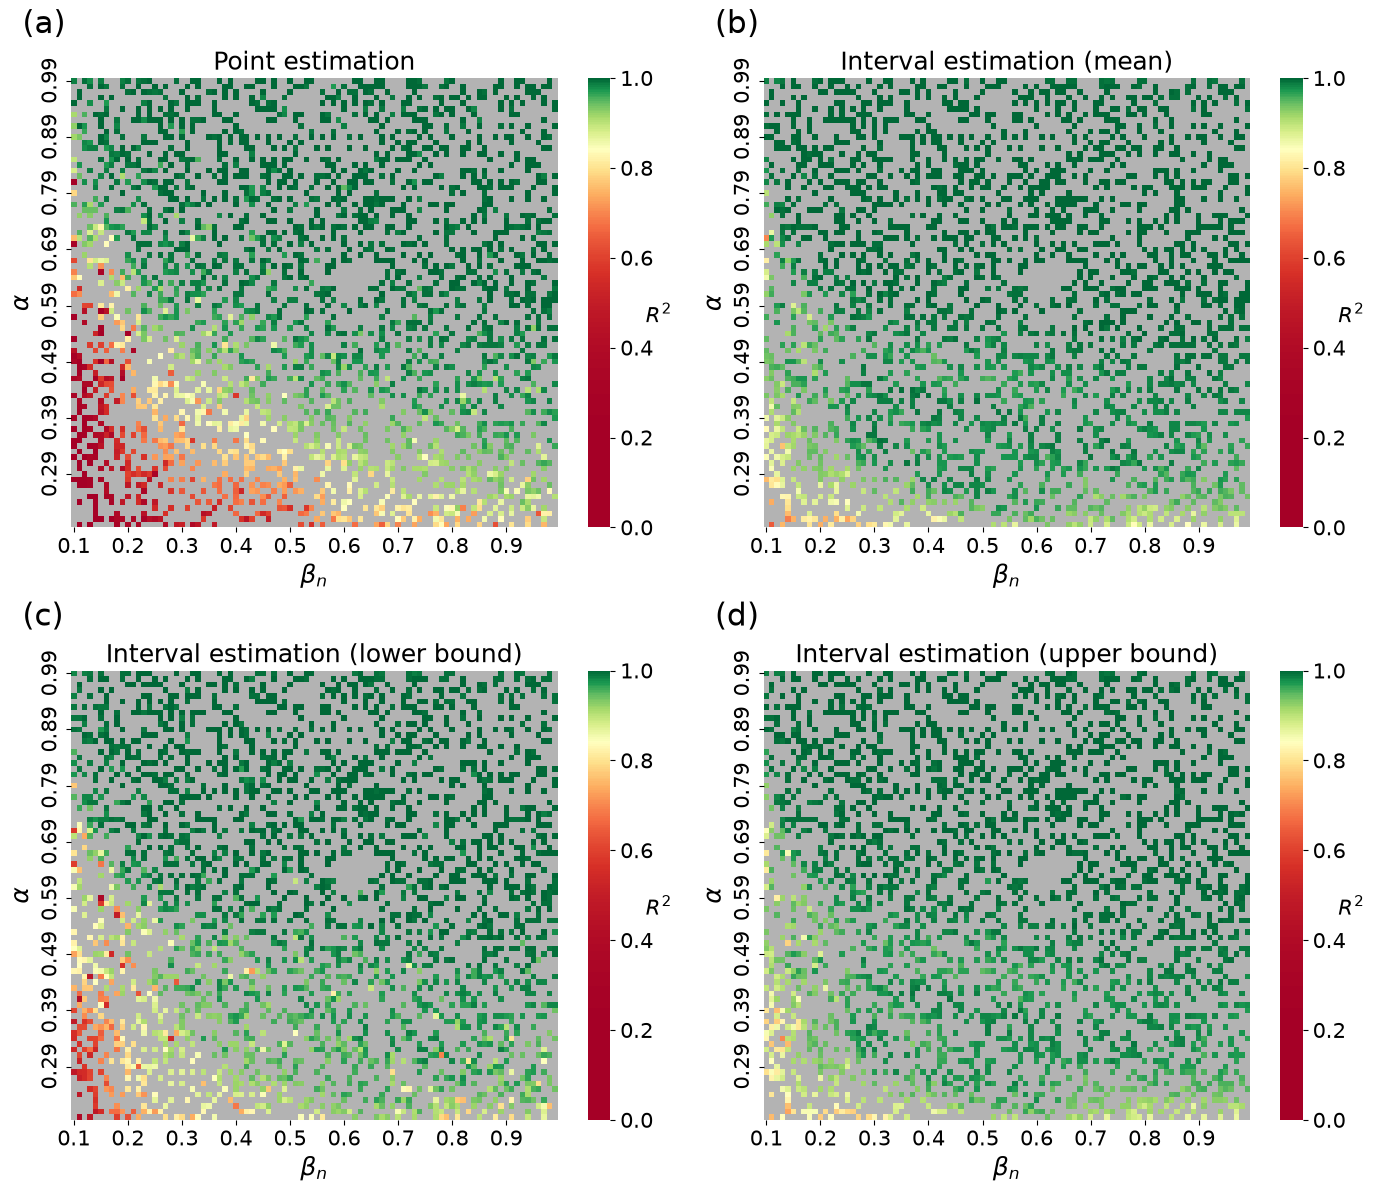

In [36]:
topology='ba'
type_df = 'point'
ae = torch.load(f'{folder_main}/calibr/models/autoencoder_{topology}_100k_n.pt', 
                weights_only=False)
X_train, y_train, X_test, y_test,tmax = \
    surr_funcs.get_splits_df(folder=folder_main+'calibr/', 
                             type_df=type_df,network_type = topology)
dd = surr_funcs.df_for_heatmap(ae, type_df,X_train, y_train, 
                               X_test, y_test, tmax)

type_df = 'interval'
ae = torch.load(f'{folder_main}/calibr/models/autoencoder_interval_{topology}_100k_n.pt', 
                weights_only=False)
X_train, y_train, X_test, y_test,tmax = \
    surr_funcs.get_splits_df(folder=folder_main+'calibr/', 
                             type_df=type_df,network_type = topology)
dd2_mean,dd2_min,dd2_high = surr_funcs.df_for_heatmap(ae, type_df, 
                                                      X_train, y_train, 
                                                      X_test, y_test, tmax)
fontsize = 15
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax=axes.flatten()

n = ['(a)','(b)','(c)','(d)'][::-1]

cmap = surr_funcs.nonlinear_cmap()
for i,heat_df, title in zip(range(4), 
                            [dd,dd2_mean,dd2_min,dd2_high], 
                            ['Point estimation','Interval estimation (mean)',
                            'Interval estimation (lower bound)',
                            'Interval estimation (upper bound)'
                            ]):
    
    ax_i = sns.heatmap(heat_df.sort_index(level=1, ascending=False), 
                       cmap=cmap, ax=ax[i], #norm=norm, 
                       cbar_kws={'extendfrac': .1,
                                #"ticks":ticks, "boundaries":boundaries
                                },
                       vmin=0, vmax=1,
                      xticklabels = 10, yticklabels=10,
                      linewidths=0.0, rasterized=True,)
    ax_i.set_title(title, fontsize=1.2*fontsize)
    ax_i.text(-0.1, 1.1, n.pop(),
              transform=ax_i.transAxes, size=1.5*fontsize)
    ax_i.collections[0].cmap.set_bad('0.7')
    ax_i.set_xlabel(r'$\beta_n$', fontsize=1.2*fontsize)
    ax_i.set_ylabel(r'$\alpha$', fontsize=1.2*fontsize)
    ax_i.tick_params(axis='both', which='major', labelsize=fontsize)
    cbar = ax_i.collections[0].colorbar
    cbar.set_label(r'$R^2$', rotation=0, size=fontsize)
        
for i in [-1,-2,-3,-4]:    
    ax_i.figure.axes[i].tick_params(labelsize=fontsize)

#ax_1.figure.axes[-1].set_ylabel(r'$R^2$', size=fontsize)
#ax_1.figure.axes[-2].set_ylabel(r'$R^2$', size=fontsize)

plt.tight_layout()

## calibrating

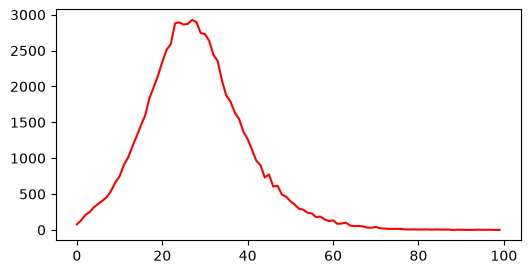

In [128]:

'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
folder='hybrid_surr/calibr/'

file=folder+'data_ba_100000.csv'
d = pd.read_csv(file, index_col=0)#.iloc[::10]
if 'init_rec_frac' in d.columns:
    d.rename(columns={'init_rec_frac':'alpha'}, inplace=True)
d.drop(columns=['gamma','delta','init_inf_frac'], inplace=True)
s = 150

plt.subplots(figsize=(6,3))

observed_data = pd.read_csv(folder+f'observed_incidence_a{true_alpha}_b{true_tau}.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)\
plt.plot(observed_data,color='red')

### one calibr plot

0.149405969205227 0.8945333434284561
sim plot time 0.27143073081970215
[1]
CPU times: total: 4.58 s
Wall time: 4.74 s


(0.149405969205227, 0.8945333434284561)

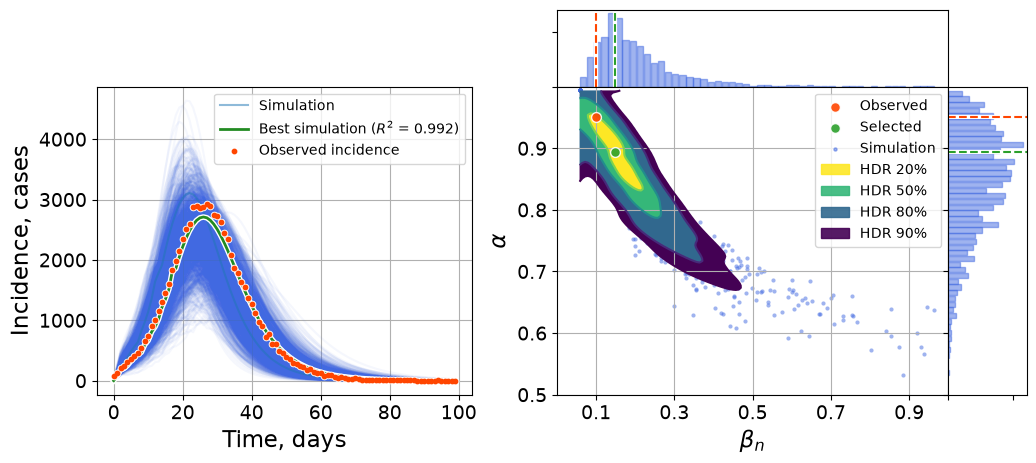

In [38]:
%%time
with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

#draws = 600
#chains = 3
top='ba'
koeff=1
shift=0
network_params=[with_switch,num_runs,frac,gamma,
                delta,n_nodes,top,koeff,shift]

idata = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1.nc")
plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params,
                     n_hyb_runs=1)
#plt.savefig(f'results/ba_hybrid.pdf', format='pdf', bbox_inches='tight')
#png.getvalue()

### 3 in 1 calibr plots

0.1615659924746181 0.8760162288835825
sim plot time 0.93941330909729
[1]
0.149405969205227 0.8945333434284561
sim plot time 0.34210753440856934
[1]
0.1512882948042508 0.8855652941232481
sim plot time 3.3020801544189453
[0]
CPU times: total: 2min 28s
Wall time: 2min 29s


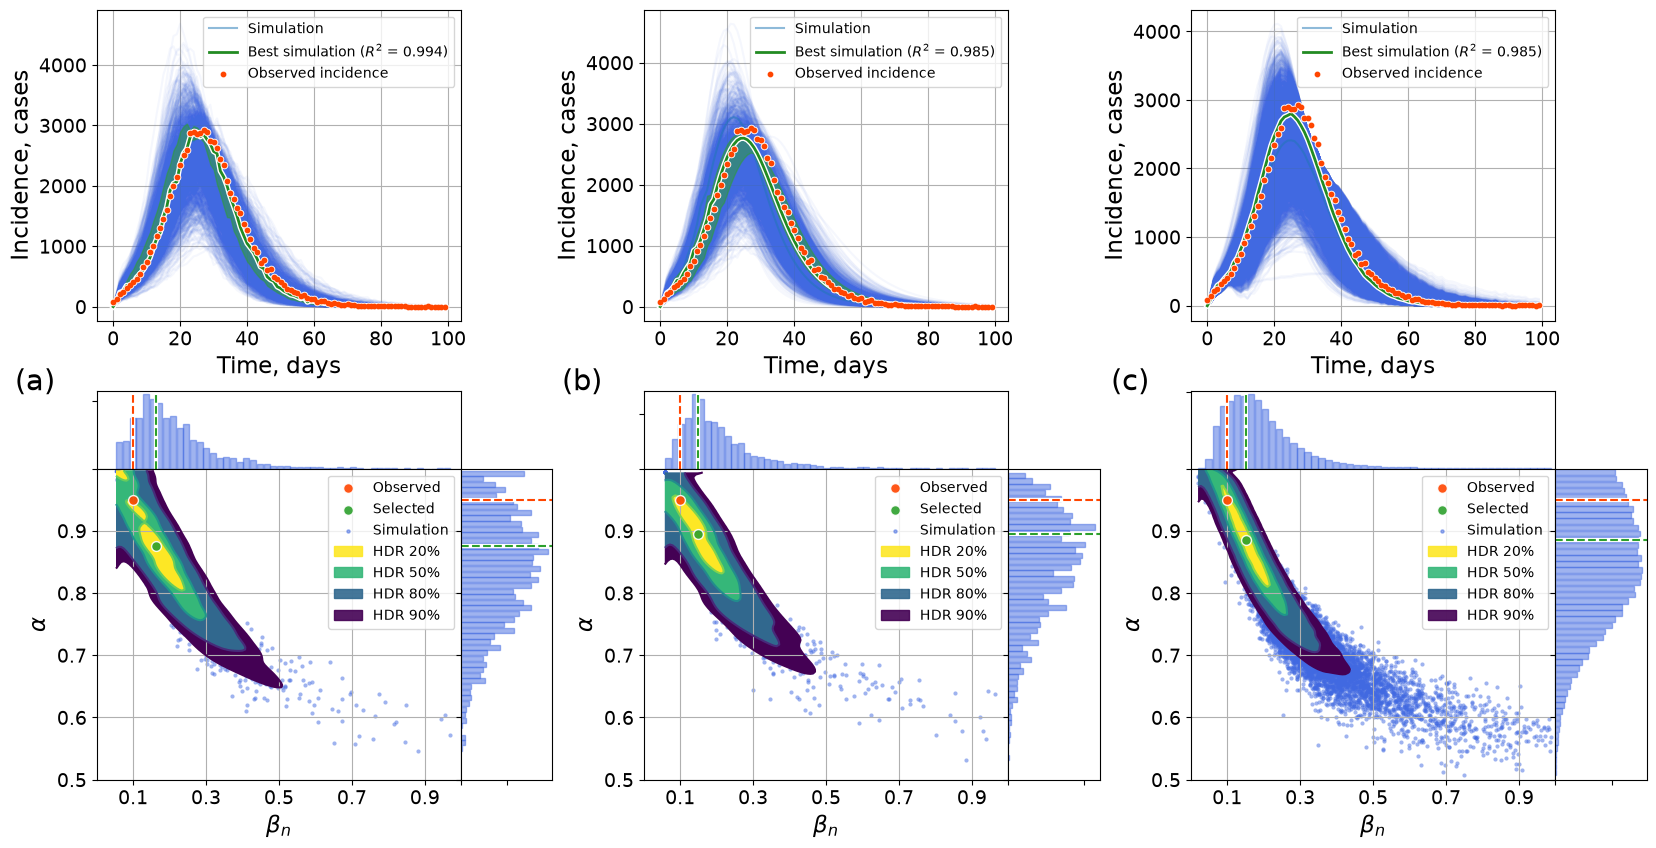

In [6]:
%%time
alphabet = 'abcdefghijklmnopqrstuvwxyz'
labels = ['('+alphabet[index] + ')' for index in range(len(alphabet))]

fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
top='ba'
idata14 = az.from_netcdf(folder+f"ba_net_a0.95_b0.1.nc")
idata7 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1.nc")
idata0 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1.nc").rename({"beta": "tau"})


with_switch=np.array(False) 
n_hyb_runs=10
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]


for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    if idx==1:
        frac=[0.05]
        with_switch=np.array(True) 
        network_params=[with_switch,num_runs,frac,gamma,
                        delta,n_nodes,top,koeff,shift]
    elif idx == 2:
        num_runs = [0]
        frac=[1]
        with_switch=np.array(False) 
        network_params=[with_switch,num_runs,frac,gamma,
                        delta,n_nodes,top,koeff,shift]

    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    beta_mode, alpha_mode = plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=False,
                          n_hyb_runs=n_hyb_runs,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')
    
#plt.savefig(f'results/ba_all_appr.pdf', bbox_inches='tight')
#plt.savefig(f'results/ba_all_appr.png', bbox_inches='tight')

### 3in1 forecast calibr HYBRID plot

0.3319899334904737 0.7018917114413784
sim plot time 0.38265228271484375
[1]
0.3124724971578574 0.7423251112435076
sim plot time 0.25195932388305664
[1]
0.09926934980124971 0.9556286086094852
sim plot time 0.23173832893371582
[1]
CPU times: total: 4.97 s
Wall time: 5.02 s


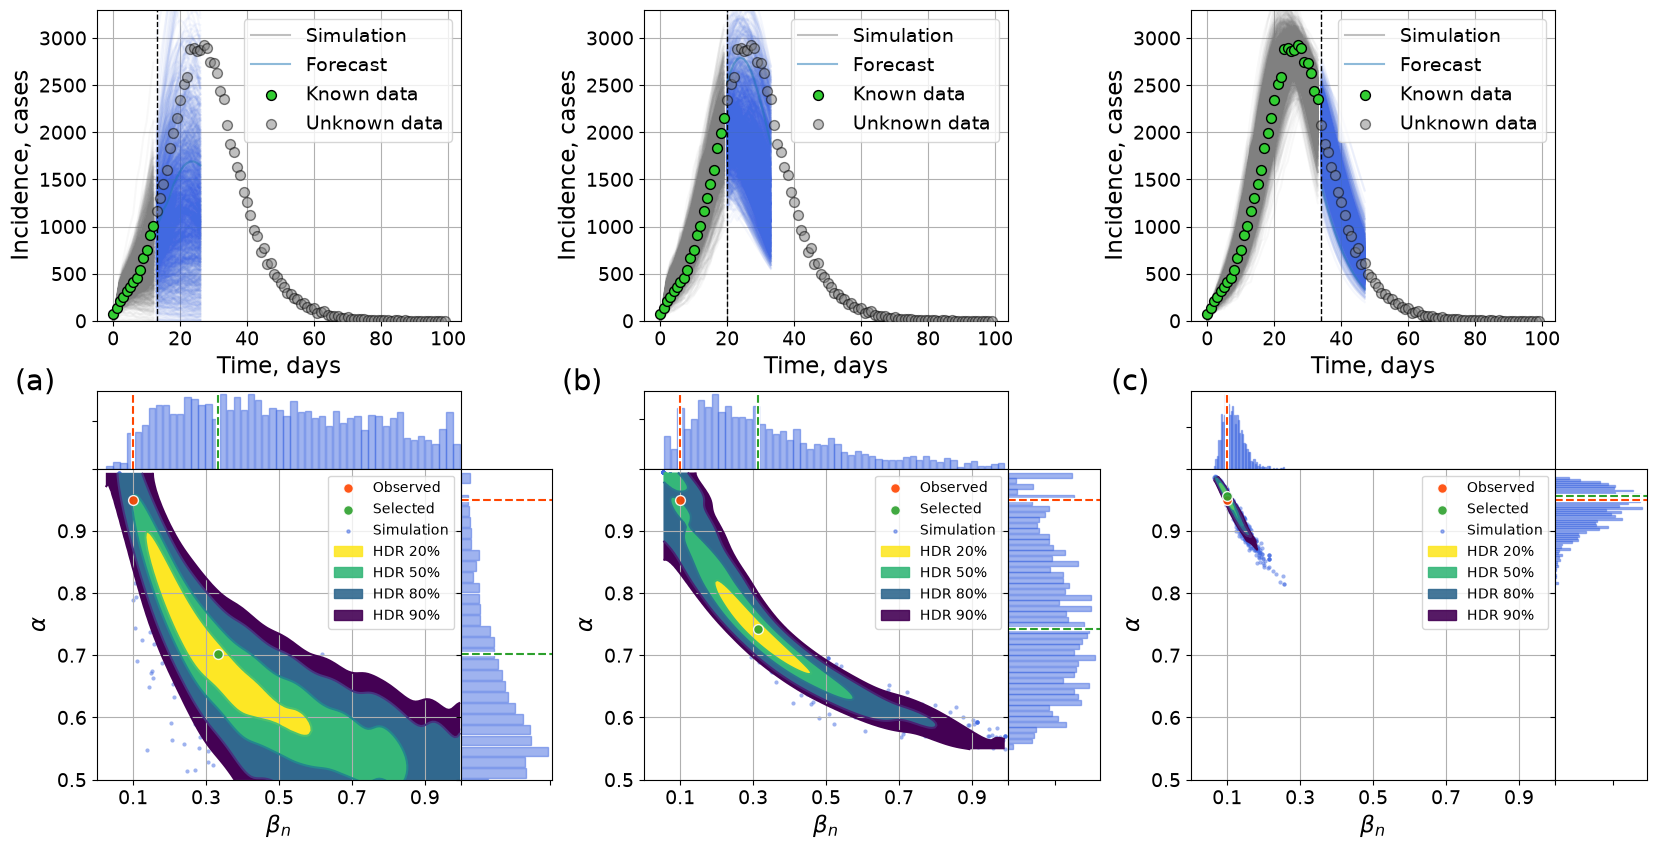

In [10]:
%%time
fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
with_switch=np.array(False) 
with_df=np.array(False) 
n_hyb_runs=1
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]

idata14 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_14b.nc")
idata7 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7b.nc")
idata0 = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7a.nc")
k=3
for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=True,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')

#plt.savefig(f'results/ba_pred_eps1000.pdf', format='pdf', bbox_inches='tight')

### 3in1 forecast calibr SURROGARE plot

0.2779829297126548 0.736795497156399
sim plot time 1.5451502799987793
[0]
0.31522334807411323 0.731988870708796
sim plot time 0.7683396339416504
[0]
0.1126073935940733 0.9358820465310027
sim plot time 0.2184743881225586
[0]
CPU times: total: 4.47 s
Wall time: 4.49 s


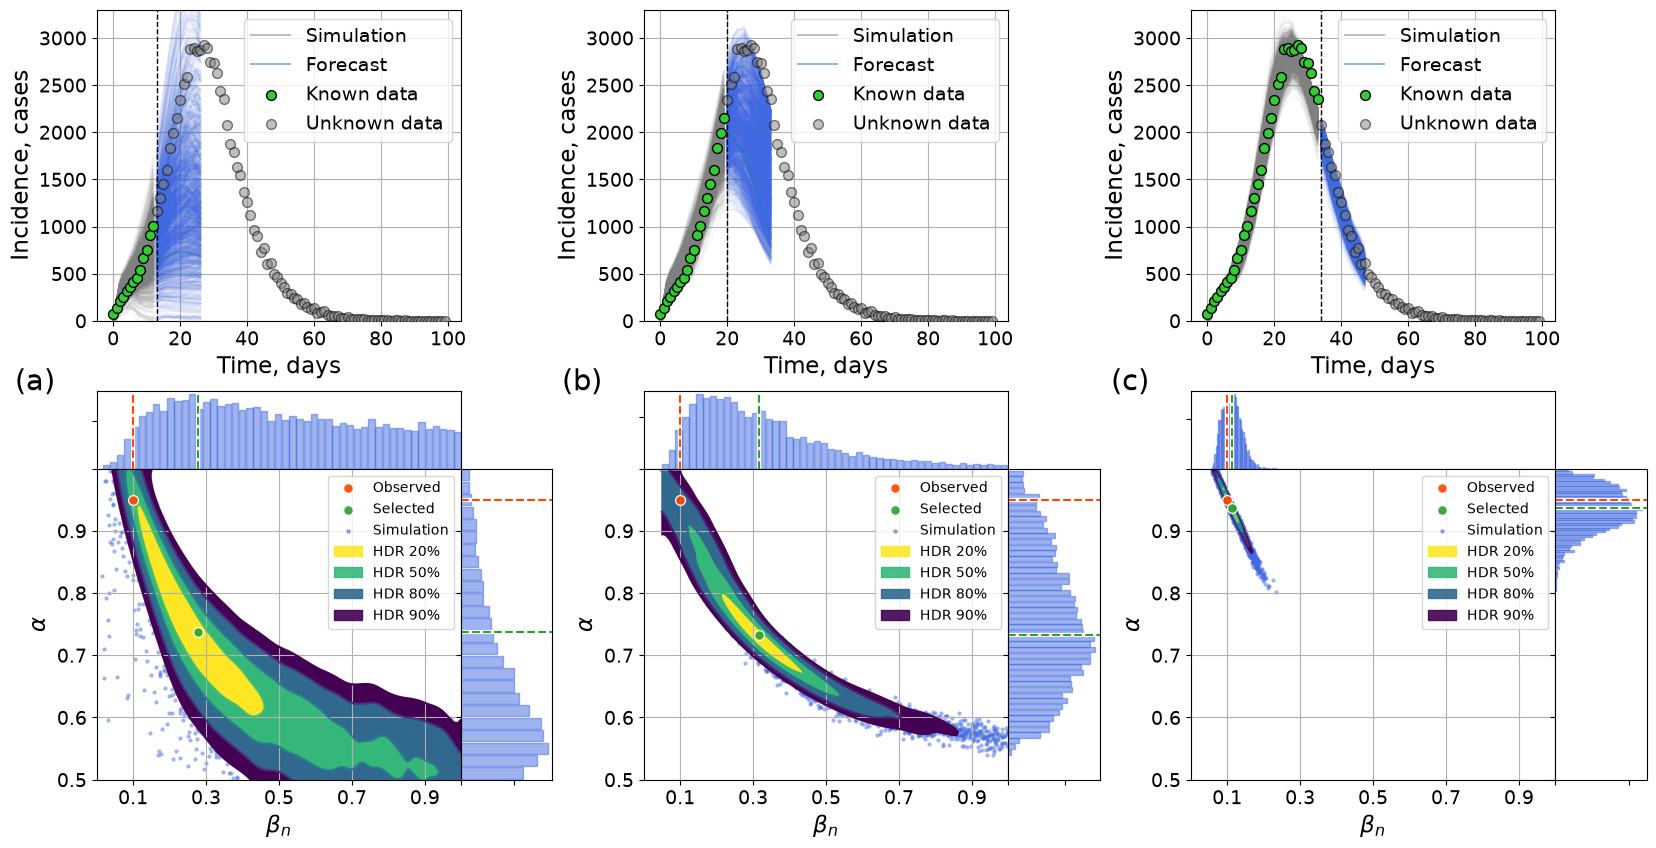

In [13]:
%%time
fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
with_switch=np.array(False) 
with_df=np.array(False) 
nth = 5
num_runs=[0]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]

idata14 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_14b.nc")
idata7 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7b.nc")
idata0 = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7a.nc")
k=3


for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=True,
                          nth=nth,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')

#plt.savefig(f'results/ba_pred_eps1000.pdf', format='pdf', bbox_inches='tight')

### plot

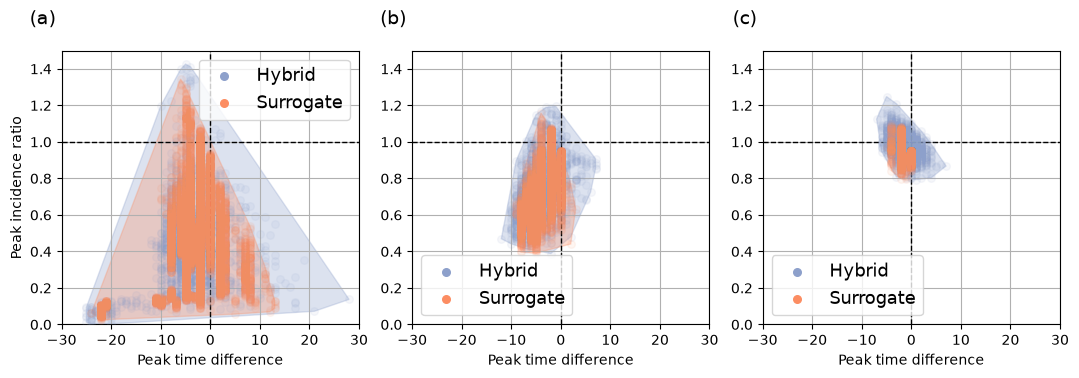

In [42]:
folder = 'hybrid_surr/calibr/'
observed_data = pd.read_csv(folder+'observed_incidence_a0.95_b0.1.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

idata14h = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_14b.nc")
idata14s = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_14b.nc")

idata7h = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7b.nc")
idata7s = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7b.nc")

idata7ah = az.from_netcdf(folder+f"ba_hyb_a0.95_b0.1_7a.nc")
idata7as = az.from_netcdf(folder+f"ba_surr_a0.95_b0.1_7a.nc")
idatas = [[idata14h, idata14s],
          [idata7h, idata7s],
          [idata7ah, idata7as]
         ]
aux_f.create_peak_plot(folder_name=folder,
                     observed_data = observed_data,
                       idatas = idatas,
                     with_outliers=True, same_lims=True, 
                     figsize=(3.6*len(idatas),4), x_lim = (-30, 30), y_lim = (0, 1.5),
                     alpha_m=0.08, alpha_area=0.3, save=False)